# Original RNN Transition Dictionary Generation

This notebook reproduces the original unperturbed RNN state-transition dictionaries used by the downstream perturbation analyses.

The generated representations include:

- Behavioral-state transitions
- Neural-state transitions
- Joint neural-behavioral transitions
- A fixed route used for subsequent analysis

In [1]:
import os
import sys
from pathlib import Path

current_dir = Path.cwd().resolve()

if (current_dir / "figure2_generation.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "figure2_generation.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise RuntimeError(f"Could not locate project root from {current_dir}")

PROJECT_ROOT = str(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Working directory:", os.getcwd())

Project root: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model
Working directory: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model


In [2]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import torch
import matplotlib.pyplot as plt

import figure2_generation as f2g
import manifold_visualization as mv
import small_model

print("Imports successful")

/Users/neelprabhakar/Python /.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful


## Baseline RNN Model

Initialize the original randomly weighted RNN using seed 42 and save its state dictionary. This model is used to generate the unperturbed transition dictionaries.

In [3]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = small_model.RNN().to(device)
model.eval()

BASELINE_MODEL_PATH = os.path.join(PROJECT_ROOT, "post_stage1_model_sd42.pt")

torch.save(model.state_dict(), BASELINE_MODEL_PATH)

print("Device:", device)
print("Baseline model saved to:", BASELINE_MODEL_PATH)

Device: mps
Baseline model saved to: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model/post_stage1_model_sd42.pt


## Neural-State Distribution Across Minimum-Visit Thresholds

Compare the neural-state distributions produced across different minimum-visit thresholds using binned outgoing-transition counts.


[Log] Generating data for min_attempts = 50...
[Log] cache already exists for min_visits=50
[Log] Completed data generation for min_attempts = 50.

[Log] Generating data for min_attempts = 55...
[Log] cache already exists for min_visits=55
[Log] Completed data generation for min_attempts = 55.

[Log] Generating data for min_attempts = 60...
[Log] cache already exists for min_visits=60
[Log] Completed data generation for min_attempts = 60.

[Log] Generating data for min_attempts = 65...
[Log] cache already exists for min_visits=65
[Log] Completed data generation for min_attempts = 65.

[Log] Generating data for min_attempts = 70...
[Log] cache already exists for min_visits=70
[Log] Completed data generation for min_attempts = 70.

[Log] Generating data for min_attempts = 75...
[Log] cache already exists for min_visits=75
[Log] Completed data generation for min_attempts = 75.

[Log] Generating data for min_attempts = 80...
[Log] cache already exists for min_visits=80
[Log] Completed dat

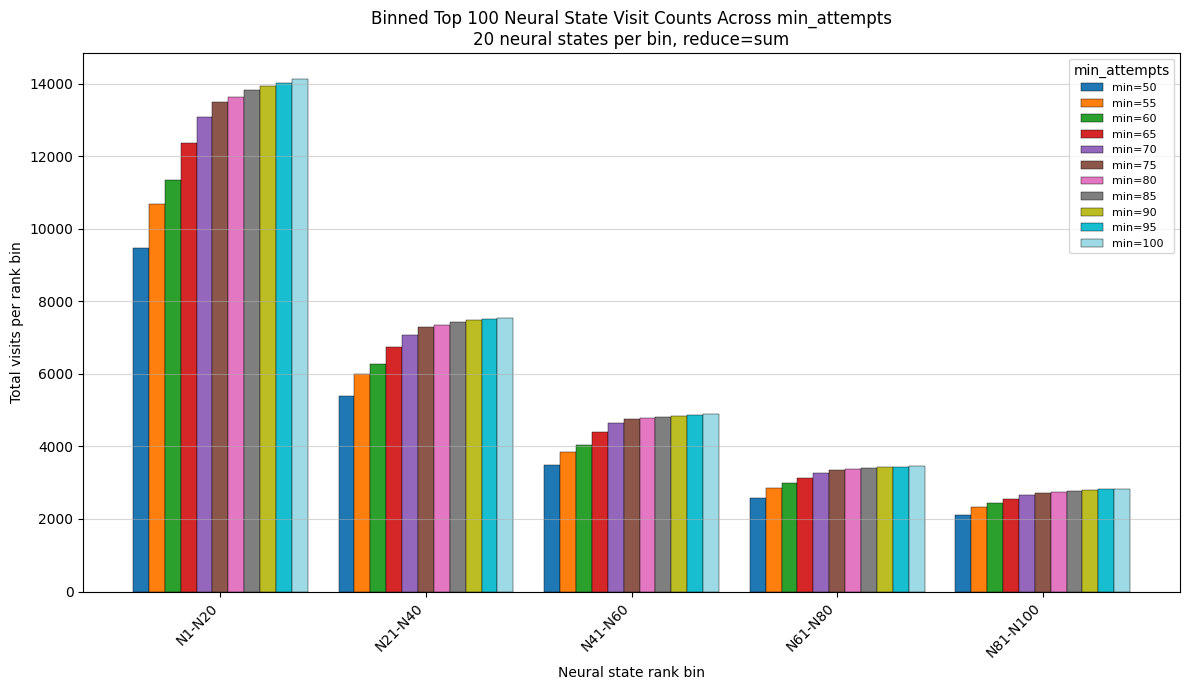

In [4]:
n_distrib_overlay = f2g.n_state_distribution_overlay_binned_barplots(model, top_k=100, bin_size=20, reduce="sum")

### Binned Neural-State Histogram Overlay


[Log] Generating data for min_attempts = 50...
[Log] cache already exists for min_visits=50
[Log] Completed data generation for min_attempts = 50.

[Log] Generating data for min_attempts = 55...
[Log] cache already exists for min_visits=55
[Log] Completed data generation for min_attempts = 55.

[Log] Generating data for min_attempts = 60...
[Log] cache already exists for min_visits=60
[Log] Completed data generation for min_attempts = 60.

[Log] Generating data for min_attempts = 65...
[Log] cache already exists for min_visits=65
[Log] Completed data generation for min_attempts = 65.

[Log] Generating data for min_attempts = 70...
[Log] cache already exists for min_visits=70
[Log] Completed data generation for min_attempts = 70.

[Log] Generating data for min_attempts = 75...
[Log] cache already exists for min_visits=75
[Log] Completed data generation for min_attempts = 75.

[Log] Generating data for min_attempts = 80...
[Log] cache already exists for min_visits=80
[Log] Completed dat

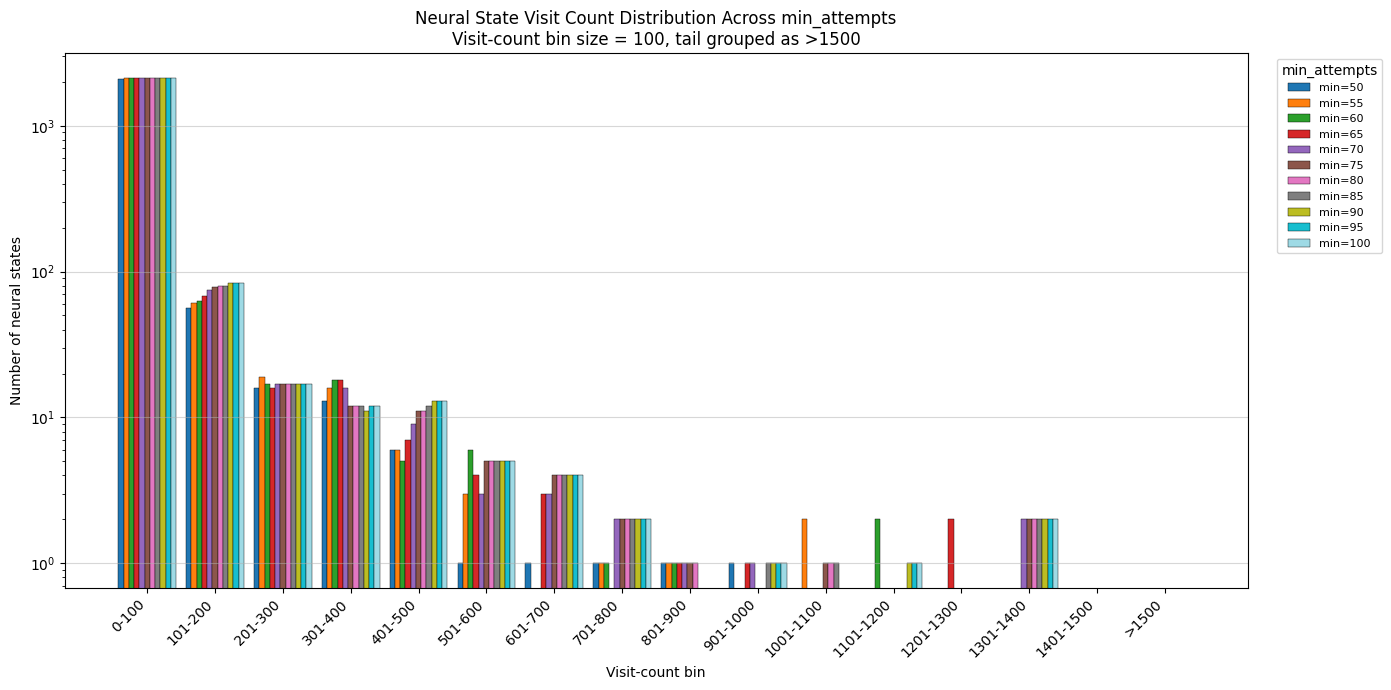

In [5]:
binned_overlay = f2g.n_state_histogram_overlay_binned(model, bin_size=100, reduce_to_same_bins=True, max_display_bin=1500)

### Neural-State Distribution Summary

In [6]:
summary = f2g.n_state_distribution_summary(model)


[Log] Generating data for min_attempts = 50...
[Log] cache already exists for min_visits=50
[Log] Completed data generation for min_attempts = 50.

[Log] Generating data for min_attempts = 55...
[Log] cache already exists for min_visits=55
[Log] Completed data generation for min_attempts = 55.

[Log] Generating data for min_attempts = 60...
[Log] cache already exists for min_visits=60
[Log] Completed data generation for min_attempts = 60.

[Log] Generating data for min_attempts = 65...
[Log] cache already exists for min_visits=65
[Log] Completed data generation for min_attempts = 65.

[Log] Generating data for min_attempts = 70...
[Log] cache already exists for min_visits=70
[Log] Completed data generation for min_attempts = 70.

[Log] Generating data for min_attempts = 75...
[Log] cache already exists for min_visits=75
[Log] Completed data generation for min_attempts = 75.

[Log] Generating data for min_attempts = 80...
[Log] cache already exists for min_visits=80
[Log] Completed dat

### Behavioral-State Distribution


[Log] Generating data for min_attempts = 50...
[Log] cache already exists for min_visits=50
[Log] Completed data generation for min_attempts = 50.

[Log] Generating data for min_attempts = 55...
[Log] cache already exists for min_visits=55
[Log] Completed data generation for min_attempts = 55.

[Log] Generating data for min_attempts = 60...
[Log] cache already exists for min_visits=60
[Log] Completed data generation for min_attempts = 60.

[Log] Generating data for min_attempts = 65...
[Log] cache already exists for min_visits=65
[Log] Completed data generation for min_attempts = 65.

[Log] Generating data for min_attempts = 70...
[Log] cache already exists for min_visits=70
[Log] Completed data generation for min_attempts = 70.

[Log] Generating data for min_attempts = 75...
[Log] cache already exists for min_visits=75
[Log] Completed data generation for min_attempts = 75.

[Log] Generating data for min_attempts = 80...
[Log] cache already exists for min_visits=80
[Log] Completed dat

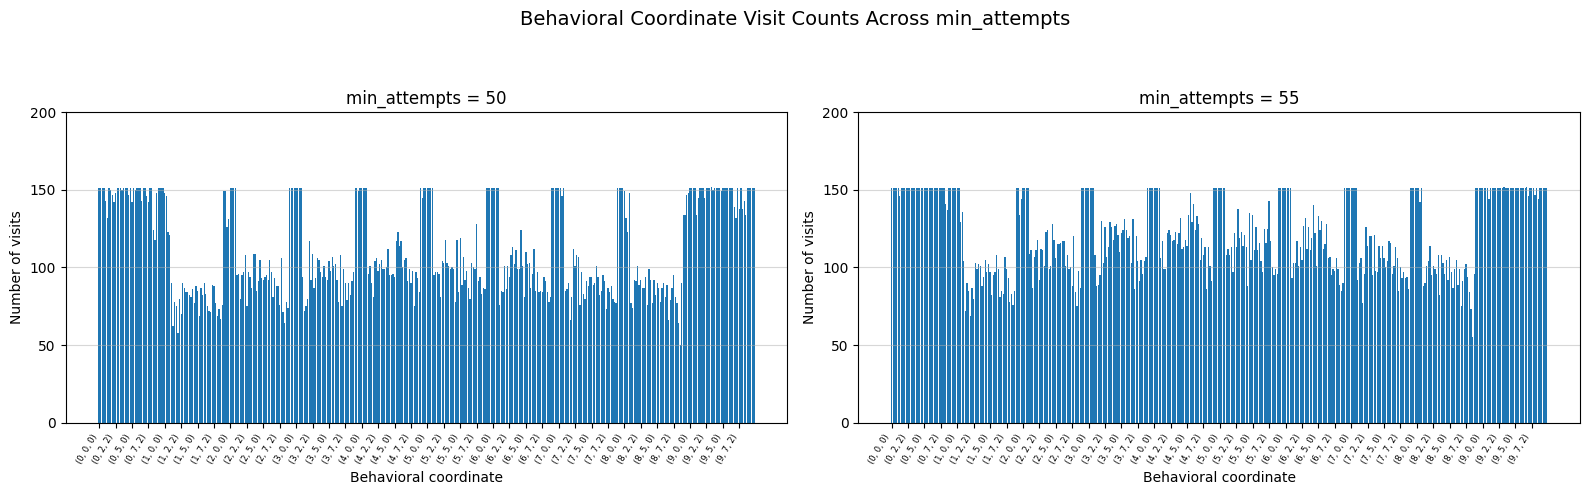

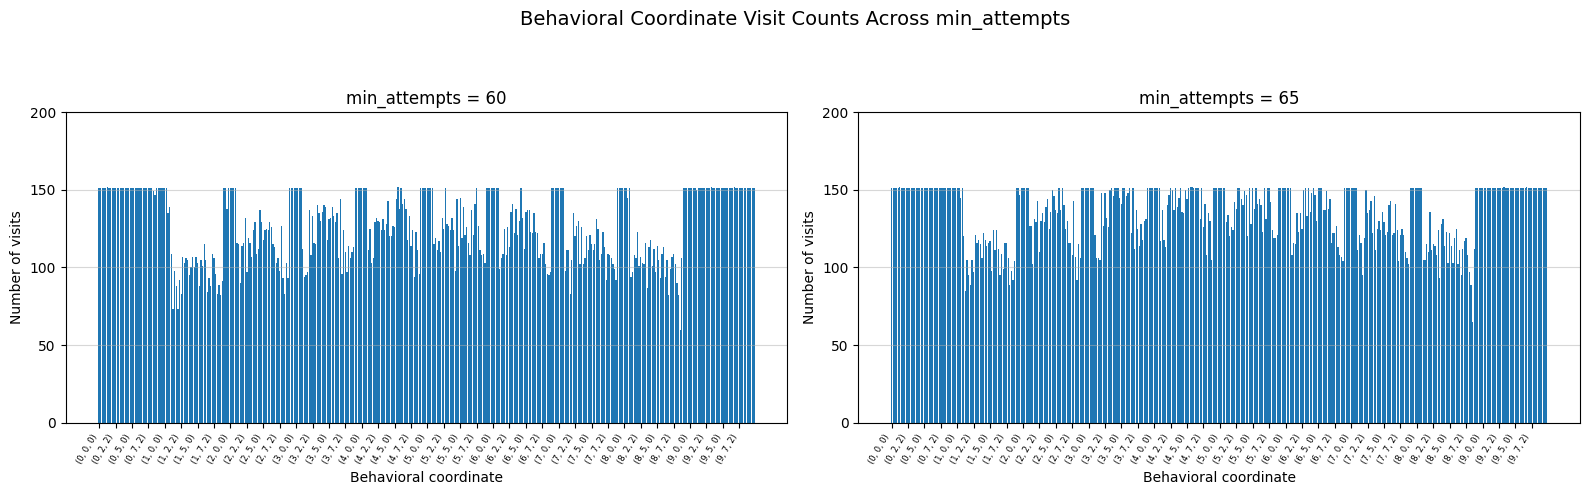

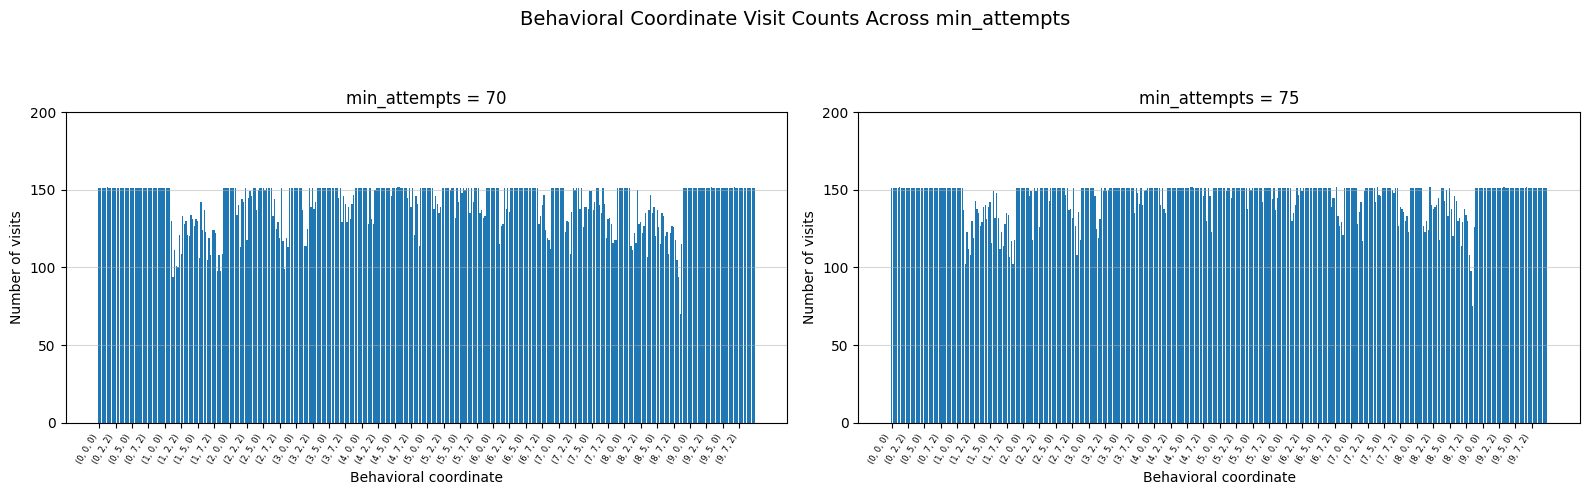

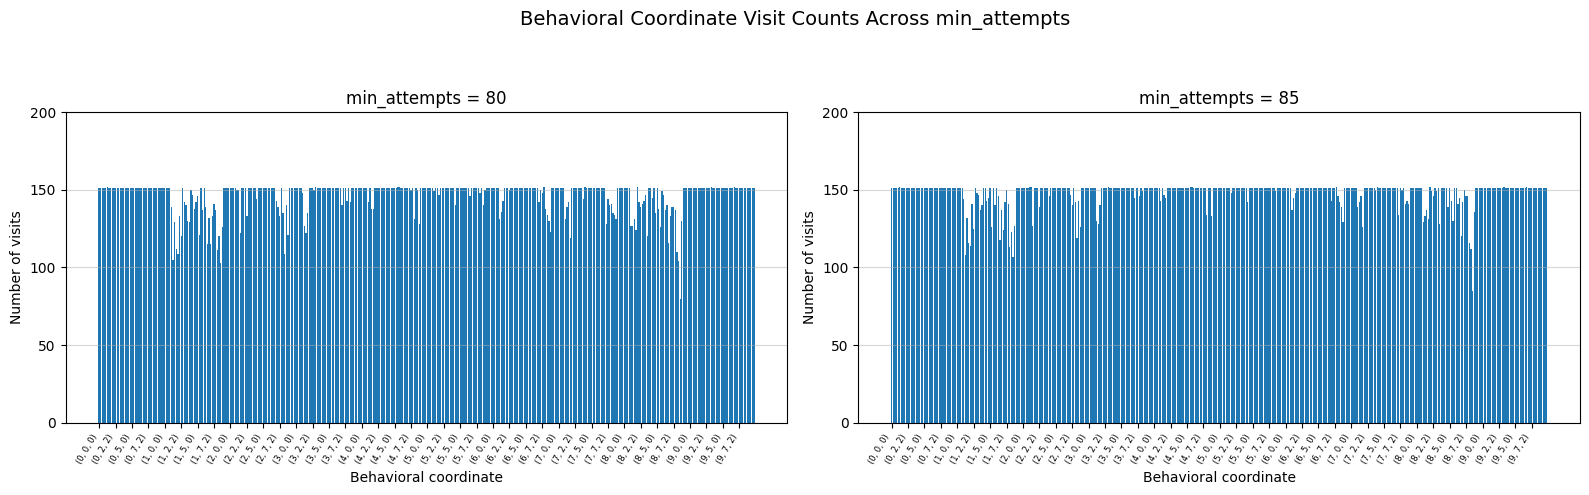

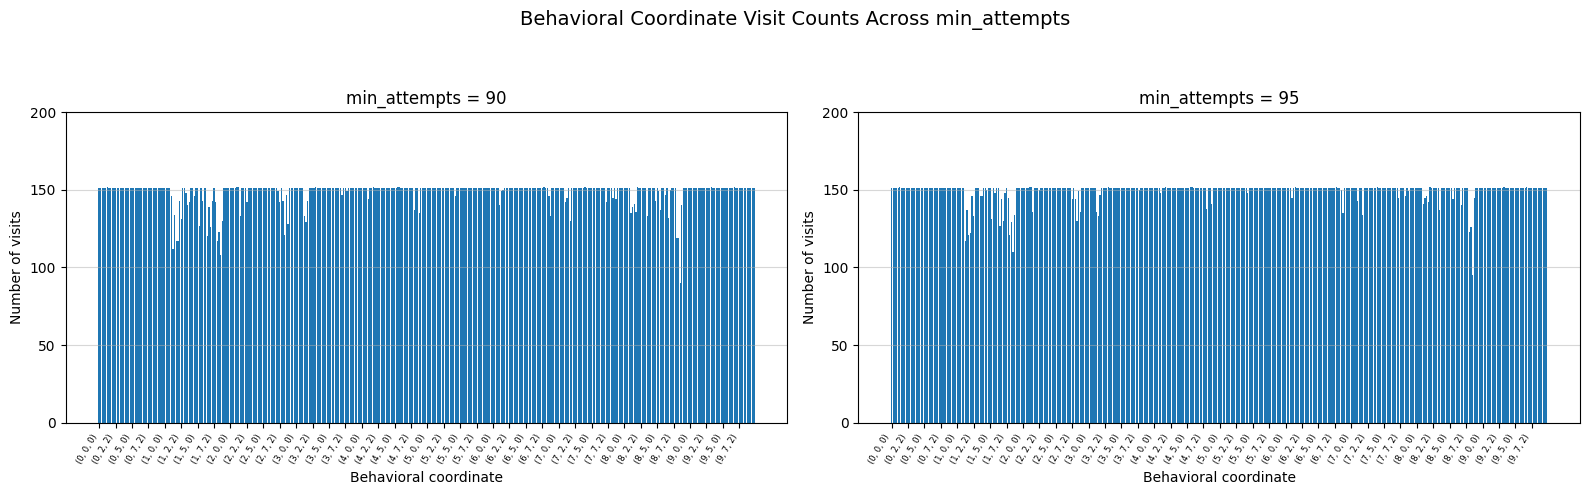

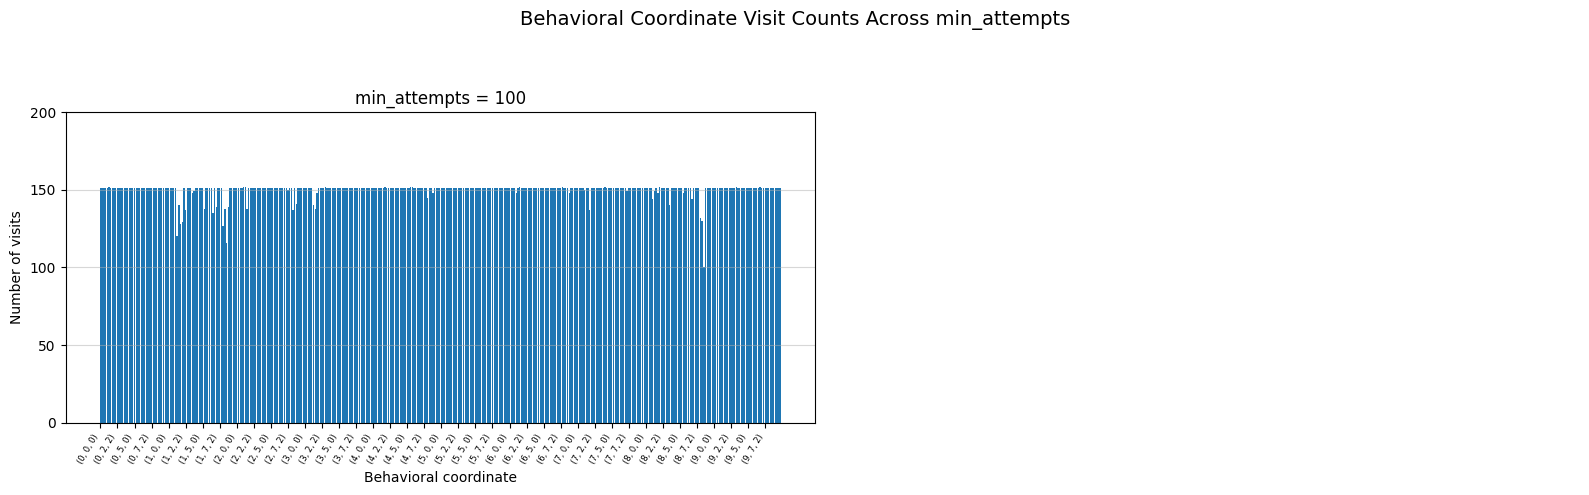

In [7]:
b_state_bar_graphs = f2g.b_state_distribution_barplots(model)

## Transition-Dictionary Sweep

Generate transition dictionaries across minimum-visit thresholds from 50 through 100 in increments of 5.

In [8]:
sweep_results = f2g.sweep_data_gen(model, step_size=5, min_attempts=50, max_attempts=101, sd=SEED)

print("Generated thresholds:", sweep_results.keys())


[Log] Generating data for min_attempts = 50...
[Log] cache already exists for min_visits=50
[Log] Completed data generation for min_attempts = 50.

[Log] Generating data for min_attempts = 55...
[Log] cache already exists for min_visits=55
[Log] Completed data generation for min_attempts = 55.

[Log] Generating data for min_attempts = 60...
[Log] cache already exists for min_visits=60
[Log] Completed data generation for min_attempts = 60.

[Log] Generating data for min_attempts = 65...
[Log] cache already exists for min_visits=65
[Log] Completed data generation for min_attempts = 65.

[Log] Generating data for min_attempts = 70...
[Log] cache already exists for min_visits=70
[Log] Completed data generation for min_attempts = 70.

[Log] Generating data for min_attempts = 75...
[Log] cache already exists for min_visits=75
[Log] Completed data generation for min_attempts = 75.

[Log] Generating data for min_attempts = 80...
[Log] cache already exists for min_visits=80
[Log] Completed dat

## Selected Transition Dictionaries

Generate the behavioral, neural, and paired transition dictionaries used for direct comparisons at selected minimum-visit thresholds.

In [9]:
pair_transition_dict_100, behavioral_transition_dict_100, neural_state_dict_100, all_visit_count_b_dict_100, all_visit_count_n_dict_100 = f2g.generate_dicts(model)
pair_transition_dict_50, behavioral_transition_dict_50, neural_state_dict_50, all_visit_count_b_dict_50, all_visit_count_n_dict_50 = f2g.generate_dicts( model, min_visits=50)
pair_transition_dict_75, behavioral_transition_dict_75, neural_state_dict_75, _, _ = f2g.generate_dicts( model, min_visits=75)

print("Transition dictionaries generated.")

[Log] cache already exists for min_visits=100
[Log] cache already exists for min_visits=50
[Log] cache already exists for min_visits=75
Transition dictionaries generated.


## Paired Transition Density

Visualize the density of unique paired neural-behavioral transitions across spatial position.

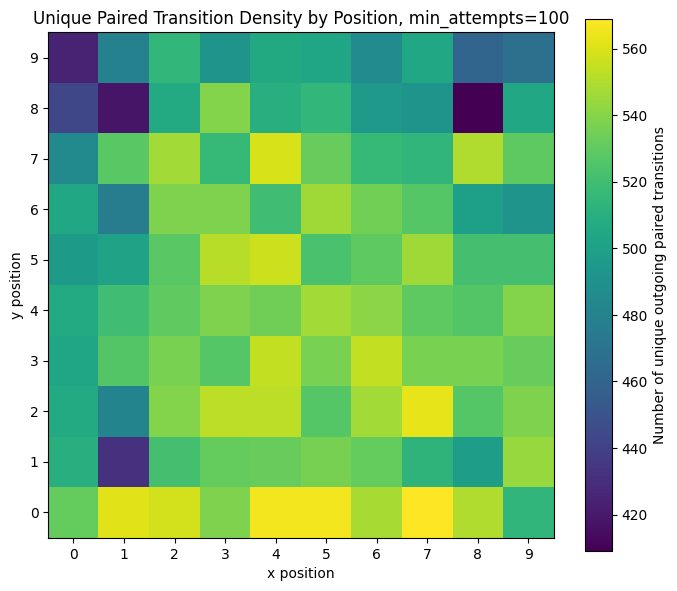

In [10]:
heatmap_pair_unique_edges_100 = f2g.paired_transition_density_heatmap(pair_transition_dict_100, grid_size=10, mode="unique_edges", title="Unique Paired Transition Density by Position, min_attempts=100")

## Fixed Supported Route

Generate a 50-step route supported by the min-visits=100 paired, neural, and behavioral transition dictionaries. The same route is subsequently evaluated using multiple transition-dictionary thresholds.

In [11]:
shared_route_sequence = f2g.generate_supported_observed_pair_route( pair_transition_dict_100, neural_state_dict_100, behavioral_transition_dict_100, route_len=50, seed=SEED, min_pair_total=3, min_pair_count=1, min_n_total=3, min_b_total=20)
print("Shared route length:", len(shared_route_sequence))

Shared route length: 50


### Fixed-Route Error at Different Minimum-Visit Thresholds

Evaluate the same route using transition dictionaries generated with minimum-visit thresholds of 50 and 100.

In [12]:
error_history_50 = f2g.evaluate_error_history_on_fixed_route(shared_route_sequence, behavioral_transition_dict_50, neural_state_dict_50, pair_transition_dict_50, top_k=3, apply_top3_filter=False)
error_history_100 = f2g.evaluate_error_history_on_fixed_route(shared_route_sequence, behavioral_transition_dict_100, neural_state_dict_100, pair_transition_dict_100, top_k=3, apply_top3_filter=False)

### Lookup Transition Animation

Run the original lookup transition sequence along the shared fixed route and save the route used by downstream perturbation analyses.

Generated support-filtered route with 50 transitions


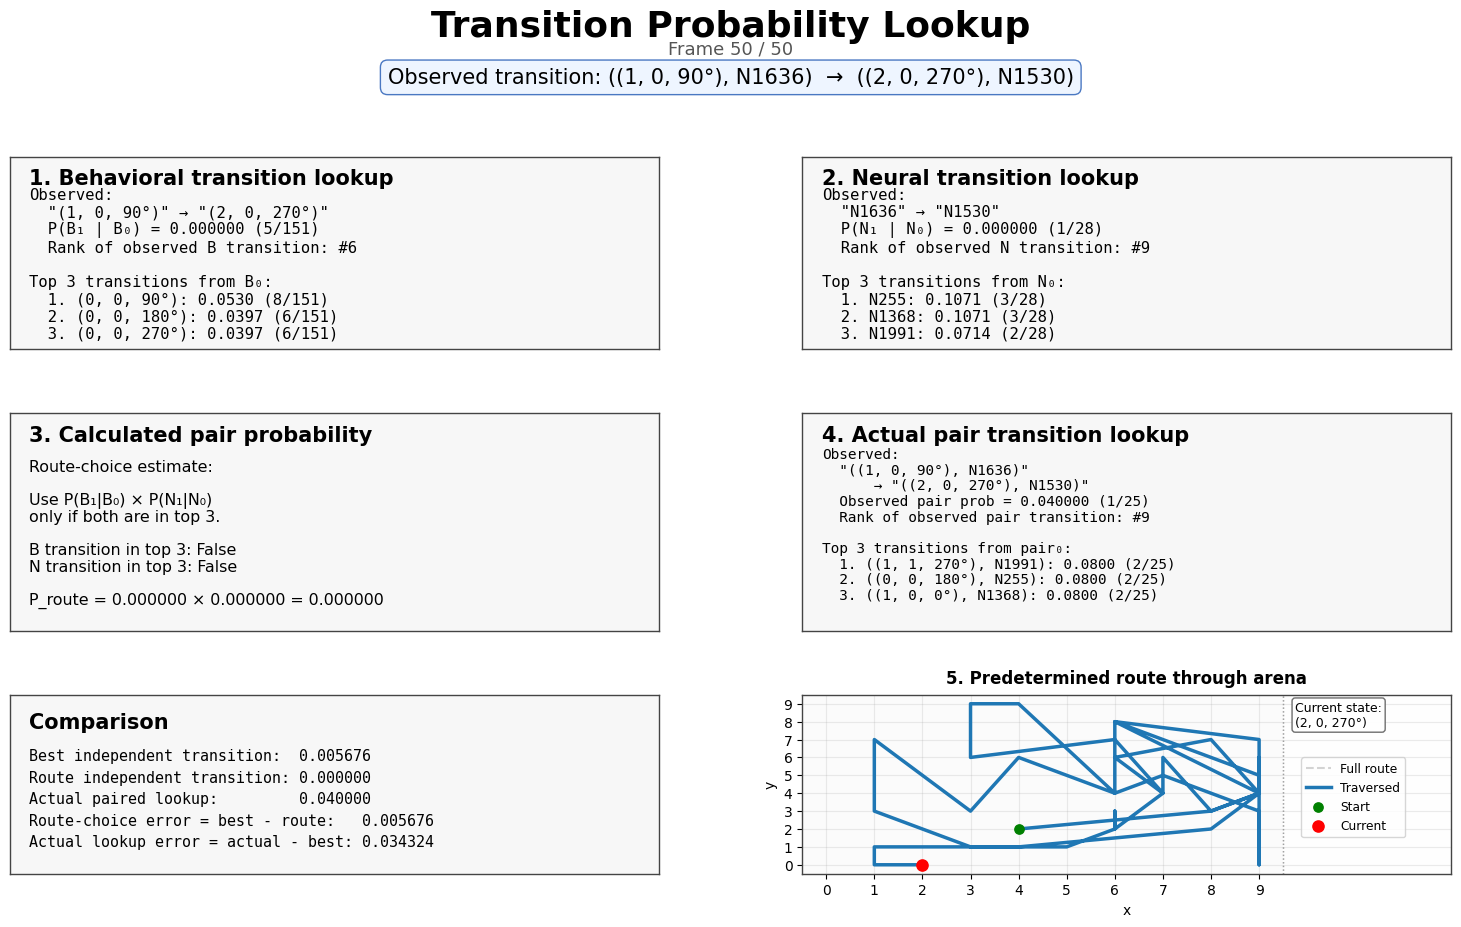

Saved fixed route.


In [13]:
_, route100, animation_error_history = f2g.animate_json_lookup_transition_clean(pair_transition_dict_100, behavioral_transition_dict_100, neural_state_dict_100, max_steps=50, interval=1200, save_path=os.path.join(PROJECT_ROOT,"lookup_animation_min100.mp4"), route_sequence=shared_route_sequence)

np.save(os.path.join(PROJECT_ROOT, "route_sequence_min100.npy"), np.array(route100, dtype=object), allow_pickle=True)

print("Saved fixed route.")

In [14]:
np.save(os.path.join(PROJECT_ROOT, "error_history_min100.npy"), np.array(error_history_100, dtype=object),allow_pickle=True)

print("Saved min-100 error history.")

Saved min-100 error history.


### Top-3 Route Transitions

In [15]:
top3_route_history_100 = f2g.save_top3_route_transitions(route100, behavioral_transition_dict_100, neural_state_dict_100, pair_transition_dict_100, top_k=3)

np.save(os.path.join(PROJECT_ROOT, "top3_route_transitions_min100.npy"), np.array(top3_route_history_100, dtype=object), allow_pickle=True)

print("Saved top-3 route transitions.")

Saved top-3 route transitions.


### Fixed-Route Error: Min-50 vs Min-100

Compare normalized transition error across the same route for dictionaries generated at two different minimum-visit thresholds.

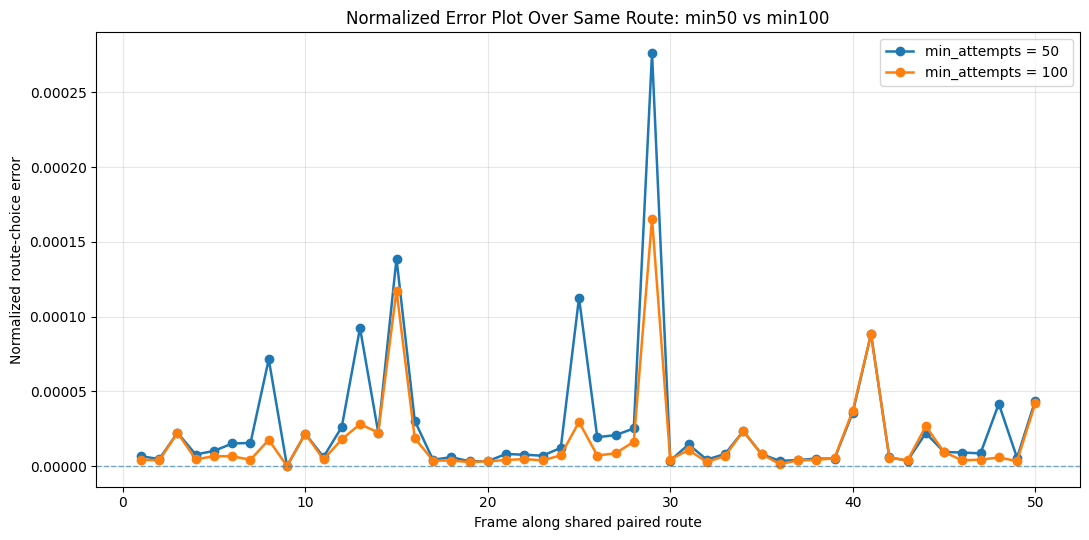

min_attempts = 50
Mean: 2.699118192401064e-05
Median: 9.233802784522158e-06
Max: 0.00027631942525559546
Min: 0.0

min_attempts = 100
Mean: 1.721449674929248e-05
Median: 6.1177749891607015e-06
Max: 0.00016556291390728477
Min: 0.0


In [16]:
error_plot_50_100 = f2g.plot_error_histories_over_time(error_history_50, error_history_100, title="Normalized Error Plot Over Same Route: min50 vs min100", use_normalized=True, show_points=True)

## Fixed-Route Coverage Summary

In [17]:
f2g.summarize_fixed_route_coverage(shared_route_sequence, behavioral_transition_dict_50, neural_state_dict_50, pair_transition_dict_50, label="min_attempts=50")
f2g.summarize_fixed_route_coverage(shared_route_sequence, behavioral_transition_dict_100, neural_state_dict_100, pair_transition_dict_100, label="min_attempts=100")


Coverage summary for min_attempts=50
----------------------------------------
Total route transitions: 50
Missing B0 states: 0/50
Missing N0 states: 0/50
Missing pair0 states: 0/50
Observed B transition missing: 8/50
Observed N transition missing: 2/50
Observed pair transition missing: 10/50

Coverage summary for min_attempts=100
----------------------------------------
Total route transitions: 50
Missing B0 states: 0/50
Missing N0 states: 0/50
Missing pair0 states: 0/50
Observed B transition missing: 0/50
Observed N transition missing: 0/50
Observed pair transition missing: 0/50


## Behavioral and Neural State Heatmaps

Visualize behavioral-state occupancy, neural-state occupancy, and their joint spatial distribution.

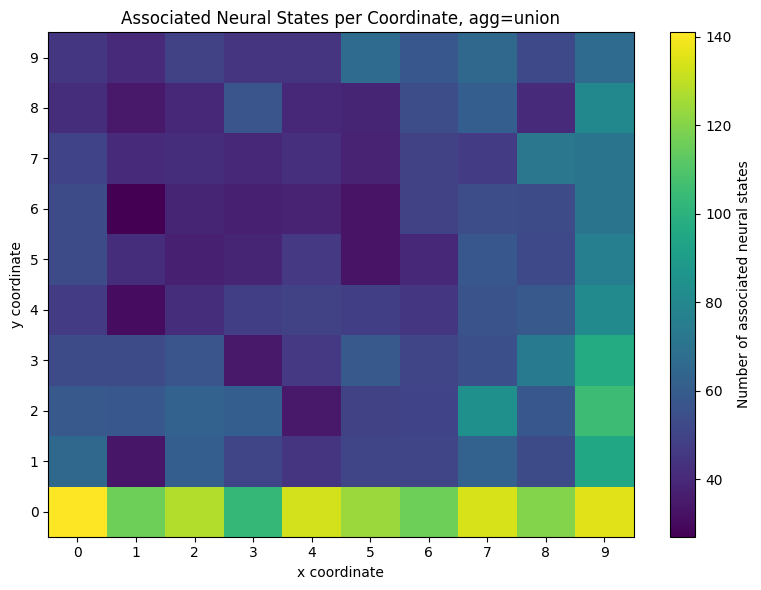

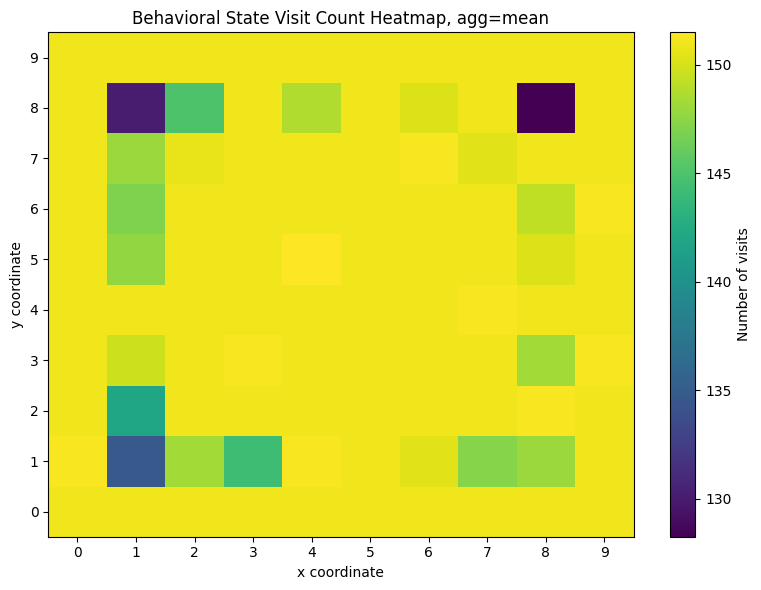

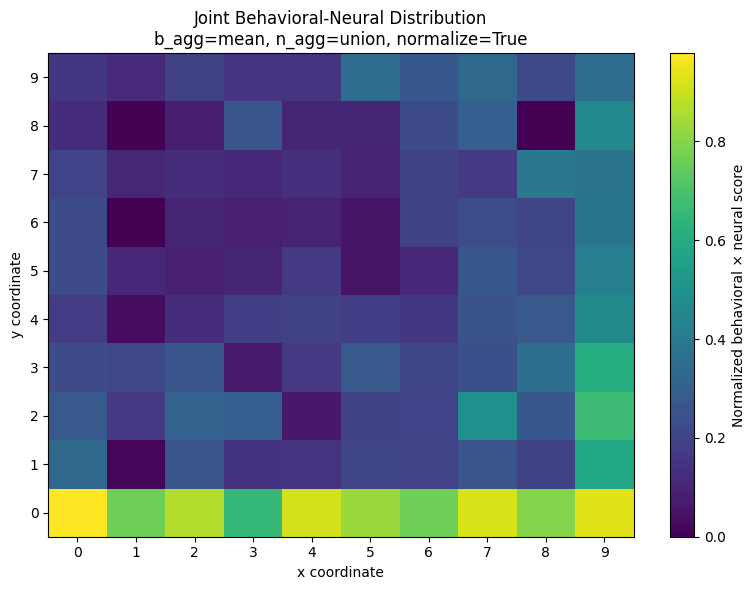

In [18]:
b_to_n_dict = f2g.build_b_to_n_map(pair_transition_dict_100)
nheat = f2g.n_state_distribution_heatmap(b_to_n_dict, agg="union")
bheat = f2g.b_state_distribution_heatmap(all_visit_count_b_dict_100, agg="mean")
joint_bn_distribution_heatmap = f2g.joint_b_n_dist_heatmap(all_visit_count_b_dict_100, b_to_n_dict, normalize=True, b_agg="mean", n_agg="union")